# 03. Modelos independientes por empresa

**Autor:** Marco Padilla Gómez  
**Experimento:** `per-company-20260916`  
**Rama:** `feature/per-company-temporal-evaluation`  
**Issue:** [#47: evaluación temporal de modelos independientes por empresa](https://github.com/maarcoopg/tfg-ml-financial-sentiment/issues/47)

## Pregunta del experimento

¿Mejora la predicción de la dirección de la siguiente sesión bursátil al entrenar un modelo distinto para AAPL, MSFT, NVDA y TSLA?

Comparamos **base**, **híbrido** e **híbrido con retardo** dentro de cada empresa y frente a modelos entrenados conjuntamente. Este cuaderno es independiente de los dos anteriores: no modifica sus resultados ni la selección de `reports/final/`.

Las tablas y figuras proceden de una ejecución real. Ejecutar este cuaderno **lee los informes guardados**, sin descargar noticias ni volver a entrenar.

## 1. Protocolo y límites

- Objetivo: 1 si el precio de cierre ajustado de la siguiente sesión supera al actual; 0 en caso contrario.
- Predicción al cierre. Las noticias publicadas después se asignan a la siguiente sesión según el calendario NASDAQ, incluidos festivos y cierres anticipados.
- Base: 14 variables financieras. Híbrido: las anteriores y 13 variables de noticias de **esa empresa**.
- Híbrido con retardo: 27 variables híbridas y el sentimiento medio y número de noticias de la sesión anterior, **29 en total**. Es `lag_1` de la revisión corregida, no el antiguo experimento de 92 variables.
- Tres bloques externos desde el 16/10/2023 hasta el 29/12/2025. Dentro de cada entrenamiento, tres divisiones temporales crecientes para elegir hiperparámetros por AUC medio.
- La purga exige que la fecha del objetivo de entrenamiento sea anterior al comienzo de validación o prueba. Imputación y escalado se ajustan únicamente con el entrenamiento.
- Cada empresa dispone de su propio ajuste y estimadores. La referencia conjunta se vuelve a entrenar en esta ejecución, con idénticas variables, rejillas, fechas y código.
- Umbral fijo de 0,5, semilla 42 y referencia de clase mayoritaria elegida solo con el entrenamiento.
- Intervalos percentiles del 95 % mediante 1.000 réplicas pareadas de bloques de 20 sesiones. No están corregidos por comparaciones múltiples ni incluyen volver a entrenar en cada réplica.

**Es una exploración sobre fechas históricas ya examinadas**, no una nueva prueba final independiente. Un máximo entre muchas combinaciones puede deberse al azar; no se evalúan rentabilidad ni costes de negociación.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import roc_auc_score

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src").is_dir() and (p / "reports").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.experiments.run_per_company import verify_pairing

RUN = ROOT / "reports/experiments/per-company-20260916"
manifest = json.loads((RUN / "manifest.json").read_text(encoding="utf-8"))
assert manifest["status"] == "complete", "La ejecución no está completa."
individual = pd.read_csv(RUN / "predictions/individual.csv", parse_dates=["Date"])
joint = pd.read_csv(RUN / "predictions/joint_reference.csv", parse_dates=["Date"])
metrics = pd.read_csv(RUN / "metrics/company_metrics.csv")
blocks = pd.read_csv(RUN / "metrics/comparison_metrics.csv")
macro = pd.read_csv(RUN / "metrics/macro_metrics.csv")
intervals = pd.read_csv(RUN / "metrics/individual_vs_joint_intervals.csv")
within = pd.read_csv(RUN / "metrics/within_company_intervals.csv")
selection = pd.read_csv(RUN / "tuning/selected_params.csv")
coverage = pd.read_csv(RUN / "coverage/coverage_by_year_ticker.csv")

COMPANIES = ["AAPL", "MSFT", "NVDA", "TSLA"]
VARIANTS = ["base", "hybrid", "lag_1"]
LABELS = {"base": "Base", "hybrid": "Híbrido", "lag_1": "Híbrido con retardo"}
MODEL_LABELS = {"logistic_regression": "Regresión logística", "random_forest": "Bosque aleatorio",
                "hist_gradient_boosting": "Potenciación por histogramas",
                "xgboost": "XGBoost", "lightgbm": "LightGBM", "dummy": "Clase mayoritaria"}
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 14)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
display(pd.DataFrame({"Dato": ["Estado", "Inicio", "Fin", "Sesiones por empresa", "Empresas"],
                      "Valor": [manifest["status"], str(individual.Date.min().date()),
                                str(individual.Date.max().date()), individual.Date.nunique(),
                                ", ".join(COMPANIES)]}))

,Dato,Valor
0,Estado,complete
1,Inicio,2023-10-16
2,Fin,2025-12-29
3,Sesiones por empresa,553
4,Empresas,"AAPL, MSFT, NVDA, TSLA"


## 2. Integridad y comparación sobre las mismas observaciones

Antes de interpretar resultados verificamos que cada pareja individual/conjunta contiene las mismas fechas, empresa, objetivo, algoritmo, variante y bloque. También recalculamos el AUC a partir de probabilidades y comprobamos las huellas SHA-256 de todos los informes de la ejecución. Los modelos y las copias locales de datos están excluidos de Git y no son necesarios para leer este cuaderno.

In [2]:
verify_pairing(individual, joint)
assert set(individual.ticker) == set(COMPANIES)
for approach, predictions in [("individual", individual), ("joint", joint)]:
    for (ticker, variant, model), frame in predictions.groupby(["ticker", "dataset_type", "model_name"]):
        expected = metrics.loc[
            (metrics.approach == approach) & (metrics.ticker == ticker)
            & (metrics.dataset_type == variant) & (metrics.model_name == model), "roc_auc"
        ].item()
        assert np.isclose(roc_auc_score(frame.target, frame.probability), expected, atol=1e-12)
checked = 0
for relative, expected_hash in manifest["output_sha256"].items():
    path = ROOT / relative
    if path.is_relative_to(RUN):
        assert path.is_file(), f"Falta el informe: {relative}"
        assert hashlib.sha256(path.read_bytes()).hexdigest() == expected_hash, relative
        checked += 1
display(Markdown(f"**Verificados:** {checked} informes y {len(individual):,} predicciones por enfoque. "
                 "Las métricas coinciden con las probabilidades guardadas."))

**Verificados:** 39 informes y 35,392 predicciones por enfoque. Las métricas coinciden con las probabilidades guardadas.

## 3. Noticias separadas por empresa

El filtro se aplica antes de calcular los retardos y de entrenar. Cada modelo utiliza exclusivamente las filas de su empresa, incluidas las puntuaciones de sentimiento específicas del activo proporcionadas por Alpha Vantage. Si un artículo menciona dos empresas puede aparecer en ambas, pero conserva la puntuación correspondiente a cada una; no se impone una exclusividad artificial de artículos.

Los archivos locales `data/experiments/per-company-20260916/<empresa>/news.csv` y `dataset.csv` permiten inspeccionar esa separación. Las noticias no registradas **no equivalen a noticias inexistentes**: la cobertura del proveedor no está certificada. La tabla siguiente muestra toda la historia disponible y el gráfico permite ver los cambios de cobertura.

,sesiones,sesiones_con_noticias,registros_utilizados,porcentaje_sesiones_con_noticias
ticker,,,,
AAPL,2764,2060,8895,74.53
MSFT,2764,2152,15250,77.86
NVDA,2764,1552,14709,56.15
TSLA,2764,1716,6916,62.08


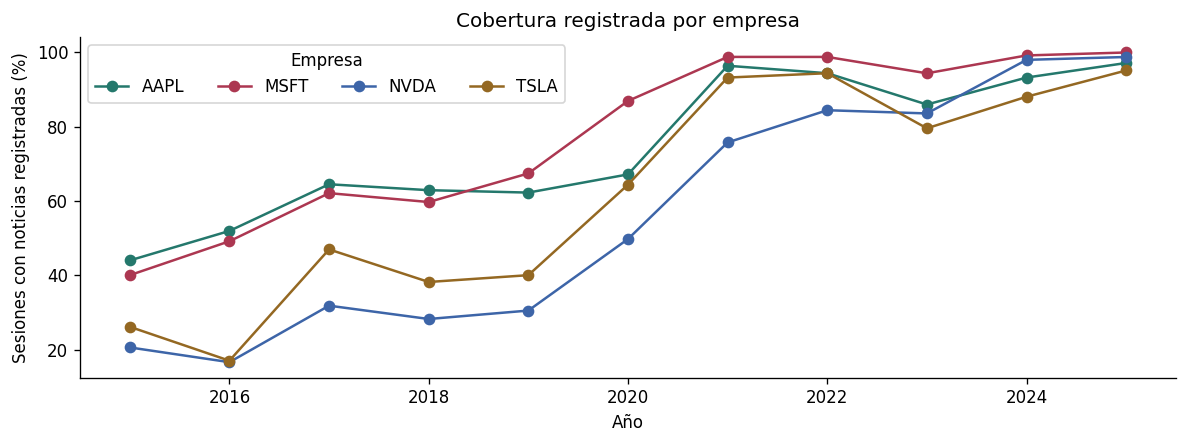

In [3]:
news_summary = coverage.groupby("ticker").agg(
    sesiones=("sessions", "sum"), sesiones_con_noticias=("recorded_news_days", "sum"),
    registros_utilizados=("recorded_news", "sum")).reindex(COMPANIES)
news_summary["porcentaje_sesiones_con_noticias"] = 100 * news_summary.sesiones_con_noticias / news_summary.sesiones
display(news_summary.round(2))
recent = coverage.pivot(index="year", columns="ticker", values="recorded_day_ratio").reindex(columns=COMPANIES)
ax = (recent * 100).plot(figsize=(10, 3.8), marker="o", color=["#24786c", "#ac3751", "#3d65a8", "#946822"])
ax.set(xlabel="Año", ylabel="Sesiones con noticias registradas (%)", title="Cobertura registrada por empresa")
ax.legend(title="Empresa", ncol=4)
plt.tight_layout()
plt.show()

## 4. Fechas, tamaño de muestra e hiperparámetros

Separar empresas reduce a una cuarta parte las observaciones disponibles para cada estimador; no crea nuevos datos. Las fechas de las divisiones permanecen compartidas. Cada combinación vuelve a elegir sus hiperparámetros utilizando solo sus tres divisiones internas. No se eligen parámetros a partir de los resultados externos de este cuaderno.

In [4]:
dates = selection[["ticker", "outer_fold", "train_rows", "test_rows", "train_end",
                   "train_target_end", "test_start", "test_end"]].drop_duplicates()
assert (pd.to_datetime(dates.train_target_end) < pd.to_datetime(dates.test_start)).all()
display(dates.rename(columns={"ticker": "Empresa", "outer_fold": "Bloque",
    "train_rows": "Filas de entrenamiento", "test_rows": "Filas de prueba",
    "train_end": "Última sesión de entrenamiento", "train_target_end": "Última etiqueta",
    "test_start": "Inicio de prueba", "test_end": "Fin de prueba"}).reset_index(drop=True))
grids = manifest["config"]["parameter_grids"]
display(pd.DataFrame([{"Algoritmo": MODEL_LABELS[model], "Configuración": i + 1,
                       "Hiperparámetros": json.dumps(params, ensure_ascii=False)}
                      for model, configs in grids.items() for i, params in enumerate(configs)]))

,Empresa,Bloque,Filas de entrenamiento,Filas de prueba,Última sesión de entrenamiento,Última etiqueta,Inicio de prueba,Fin de prueba
0,AAPL,1,2210,185,2023-10-12,2023-10-13,2023-10-16,2024-07-11
1,AAPL,2,2395,184,2024-07-10,2024-07-11,2024-07-12,2025-04-04
2,AAPL,3,2579,184,2025-04-03,2025-04-04,2025-04-07,2025-12-29
3,MSFT,1,2210,185,2023-10-12,2023-10-13,2023-10-16,2024-07-11
4,MSFT,2,2395,184,2024-07-10,2024-07-11,2024-07-12,2025-04-04
5,MSFT,3,2579,184,2025-04-03,2025-04-04,2025-04-07,2025-12-29
6,NVDA,1,2210,185,2023-10-12,2023-10-13,2023-10-16,2024-07-11
7,NVDA,2,2395,184,2024-07-10,2024-07-11,2024-07-12,2025-04-04
8,NVDA,3,2579,184,2025-04-03,2025-04-04,2025-04-07,2025-12-29
9,TSLA,1,2210,185,2023-10-12,2023-10-13,2023-10-16,2024-07-11


,Algoritmo,Configuración,Hiperparámetros
0,Regresión logística,1,"{""model__C"": 0.1}"
1,Regresión logística,2,"{""model__C"": 10.0}"
2,Bosque aleatorio,1,"{""model__n_estimators"": 100, ""model__max_depth..."
3,Bosque aleatorio,2,"{""model__n_estimators"": 100, ""model__max_depth..."
4,Potenciación por histogramas,1,"{""model__max_iter"": 100, ""model__max_leaf_node..."
5,Potenciación por histogramas,2,"{""model__max_iter"": 100, ""model__max_leaf_node..."
6,XGBoost,1,"{""model__n_estimators"": 100, ""model__max_depth..."
7,XGBoost,2,"{""model__n_estimators"": 100, ""model__max_depth..."
8,LightGBM,1,"{""model__n_estimators"": 100, ""model__num_leave..."
9,LightGBM,2,"{""model__n_estimators"": 100, ""model__num_leave..."


## 5. Referencia sencilla: clase mayoritaria

La exactitud es la proporción de aciertos, pero puede resultar alta por el desequilibrio entre subidas y bajadas. Por eso mostramos también exactitud equilibrada, F1 macro y MCC. El AUC evalúa la ordenación de las probabilidades, no el porcentaje de aciertos: 0,5 es la referencia sin discriminación. Un F1 de la clase positiva alto por sí solo no demuestra utilidad.

In [5]:
baseline = metrics[(metrics.approach == "individual") & (metrics.model_name == "dummy")]
display(baseline[["ticker", "accuracy", "balanced_accuracy", "roc_auc", "f1_macro", "mcc"]]
        .set_index("ticker").round(4))
test_balance = individual[(individual.dataset_type == "base") & (individual.model_name == "dummy")]
display(test_balance.groupby("ticker").target.agg(sesiones="size", proporcion_subidas="mean").round(4))

,accuracy,balanced_accuracy,roc_auc,f1_macro,mcc
ticker,,,,,
AAPL,0.5443,0.5,0.5,0.3525,0.0
MSFT,0.5497,0.5,0.5,0.3547,0.0
NVDA,0.5497,0.5,0.5,0.3547,0.0
TSLA,0.5118,0.5,0.5,0.3385,0.0


,sesiones,proporcion_subidas
ticker,,
AAPL,553,0.5443
MSFT,553,0.5497
NVDA,553,0.5497
TSLA,553,0.5118


## 6. Base, híbrido y retardo por empresa

Cada tabla presenta **todos los algoritmos**, no solo el que sale mejor. Las columnas comparan la variante individual y su referencia conjunta sobre las mismas 553 sesiones de esa empresa. Los valores son AUC calculados sobre todas sus predicciones externas; la estabilidad por bloque se examina después.

El color del gráfico está centrado en 0,5 y es común a las cuatro empresas. Diferencias pequeñas o un máximo aislado necesitan contrastarse con los intervalos y con la estabilidad temporal.

### AAPL

,Conjunto: Base,Conjunto: Híbrido,Conjunto: Híbrido con retardo,Individual: Base,Individual: Híbrido,Individual: Híbrido con retardo
model_name,,,,,,
Potenciación por histogramas,0.4619,0.4707,0.4851,0.4512,0.4709,0.4702
LightGBM,0.4746,0.4873,0.4825,0.4632,0.4355,0.4668
Regresión logística,0.4495,0.4688,0.4694,0.4270,0.4458,0.4536
Bosque aleatorio,0.5292,0.4926,0.4947,0.4413,0.4414,0.4411
XGBoost,0.4586,0.4802,0.4883,0.4663,0.4507,0.4639


### MSFT

,Conjunto: Base,Conjunto: Híbrido,Conjunto: Híbrido con retardo,Individual: Base,Individual: Híbrido,Individual: Híbrido con retardo
model_name,,,,,,
Potenciación por histogramas,0.4891,0.4883,0.4757,0.5141,0.5123,0.4996
LightGBM,0.4775,0.4862,0.4803,0.5097,0.5028,0.5075
Regresión logística,0.5220,0.5039,0.4949,0.4945,0.4939,0.4946
Bosque aleatorio,0.4889,0.4852,0.4865,0.5058,0.5069,0.5024
XGBoost,0.5048,0.5034,0.4976,0.4923,0.4948,0.4941


### NVDA

,Conjunto: Base,Conjunto: Híbrido,Conjunto: Híbrido con retardo,Individual: Base,Individual: Híbrido,Individual: Híbrido con retardo
model_name,,,,,,
Potenciación por histogramas,0.4742,0.4837,0.4956,0.5224,0.5048,0.5193
LightGBM,0.4921,0.4940,0.5188,0.5106,0.5112,0.5158
Regresión logística,0.5180,0.5189,0.5192,0.4879,0.5110,0.5067
Bosque aleatorio,0.4875,0.5180,0.5309,0.4970,0.5026,0.5012
XGBoost,0.4899,0.4920,0.5035,0.5190,0.5304,0.5242


### TSLA

,Conjunto: Base,Conjunto: Híbrido,Conjunto: Híbrido con retardo,Individual: Base,Individual: Híbrido,Individual: Híbrido con retardo
model_name,,,,,,
Potenciación por histogramas,0.5133,0.5418,0.5173,0.4984,0.5118,0.4949
LightGBM,0.5155,0.5078,0.4984,0.5052,0.5221,0.5210
Regresión logística,0.5167,0.5033,0.5008,0.5260,0.5227,0.5324
Bosque aleatorio,0.5173,0.5256,0.5242,0.5097,0.5267,0.5196
XGBoost,0.5139,0.5198,0.5089,0.5193,0.5304,0.5088


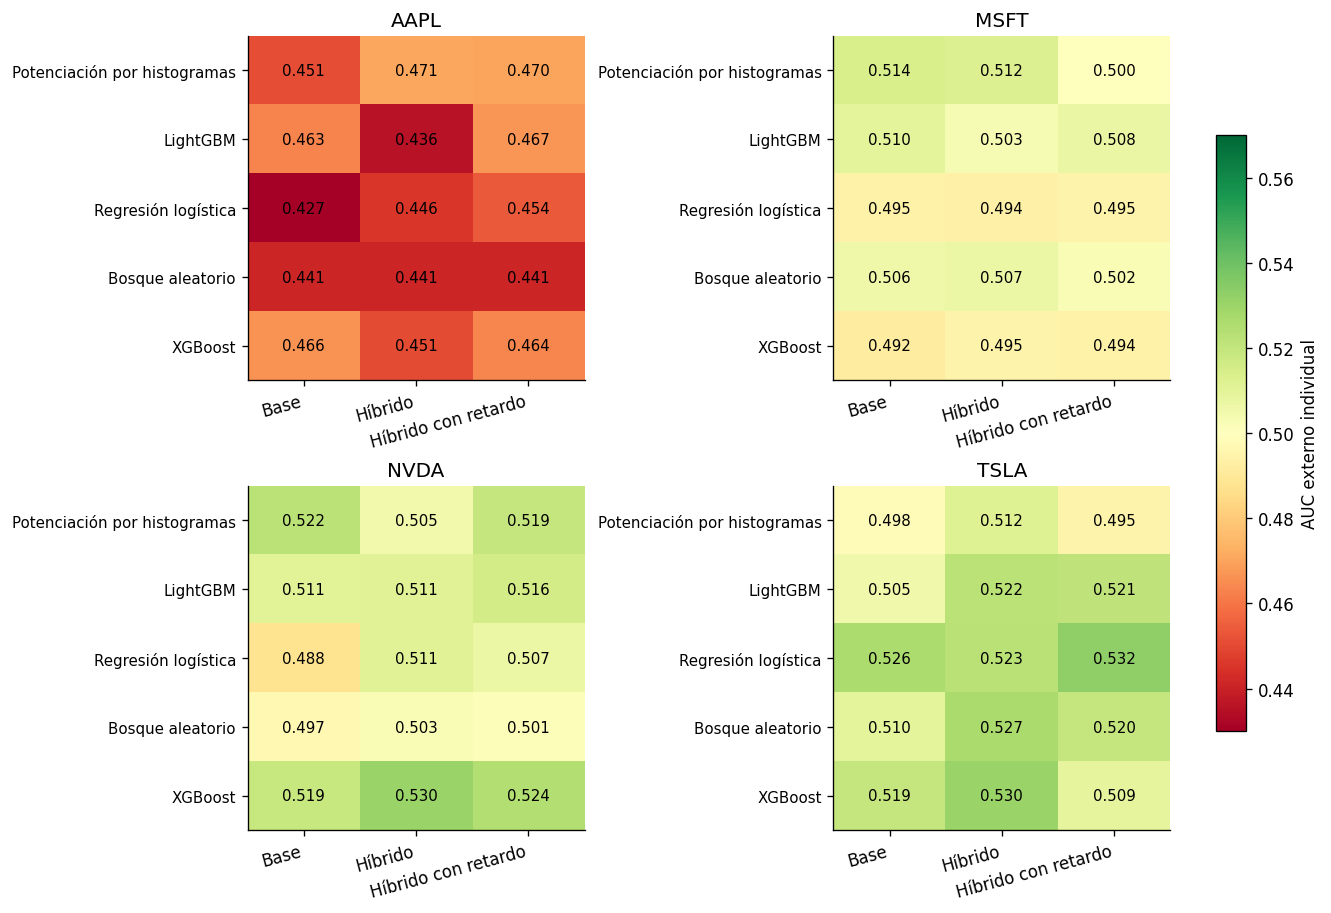

In [6]:
learned = metrics[metrics.model_name != "dummy"].copy()
for ticker in COMPANIES:
    table = learned[learned.ticker == ticker].pivot(
        index="model_name", columns=["approach", "dataset_type"], values="roc_auc")
    table = table.reindex(columns=pd.MultiIndex.from_product([["joint", "individual"], VARIANTS]))
    table.index = table.index.map(MODEL_LABELS)
    table.columns = [f"{'Conjunto' if a == 'joint' else 'Individual'}: {LABELS[v]}" for a, v in table.columns]
    display(Markdown(f"### {ticker}"))
    display(table.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), layout="constrained")
for ticker, ax in zip(COMPANIES, axes.flat):
    table = learned[(learned.ticker == ticker) & (learned.approach == "individual")].pivot(
        index="model_name", columns="dataset_type", values="roc_auc").reindex(columns=VARIANTS)
    im = ax.imshow(table, vmin=0.43, vmax=0.57, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(3), [LABELS[v] for v in VARIANTS], rotation=15, ha="right")
    ax.set_yticks(range(len(table)), [MODEL_LABELS[m] for m in table.index], fontsize=9)
    ax.set_title(ticker)
    for row in range(len(table)):
        for col in range(3):
            ax.text(col, row, f"{table.iloc[row, col]:.3f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=axes.ravel().tolist(), label="AUC externo individual", shrink=0.75)
plt.show()

## 7. ¿Mejora realmente separar empresas?

La diferencia es **AUC individual menos AUC conjunto**, manteniendo empresa, algoritmo y variante. Un intervalo que cruza cero no permite afirmar una mejora o un empeoramiento claro con este procedimiento. Las 60 comparaciones son exploratorias: un intervalo aislado que excluya cero no basta para establecer una conclusión confirmatoria.

El gráfico presenta los cinco algoritmos para las tres variantes, sin seleccionar retrospectivamente un ganador.

,ticker,dataset_type,model_name,roc_auc,auc_delta,delta_low,delta_high
0,AAPL,base,hist_gradient_boosting,0.4512,-0.0107,-0.0608,0.0301
1,AAPL,base,lightgbm,0.4632,-0.0113,-0.0655,0.0358
2,AAPL,base,logistic_regression,0.4270,-0.0224,-0.0711,0.0239
3,AAPL,base,random_forest,0.4413,-0.0879,-0.1378,-0.0411
4,AAPL,base,xgboost,0.4663,0.0077,-0.0509,0.0568
5,AAPL,hybrid,hist_gradient_boosting,0.4709,0.0002,-0.0598,0.0461
6,AAPL,hybrid,lightgbm,0.4355,-0.0518,-0.1056,-0.0004
7,AAPL,hybrid,logistic_regression,0.4458,-0.0230,-0.0638,0.0184
8,AAPL,hybrid,random_forest,0.4414,-0.0512,-0.1058,0.0016
9,AAPL,hybrid,xgboost,0.4507,-0.0294,-0.0893,0.0209


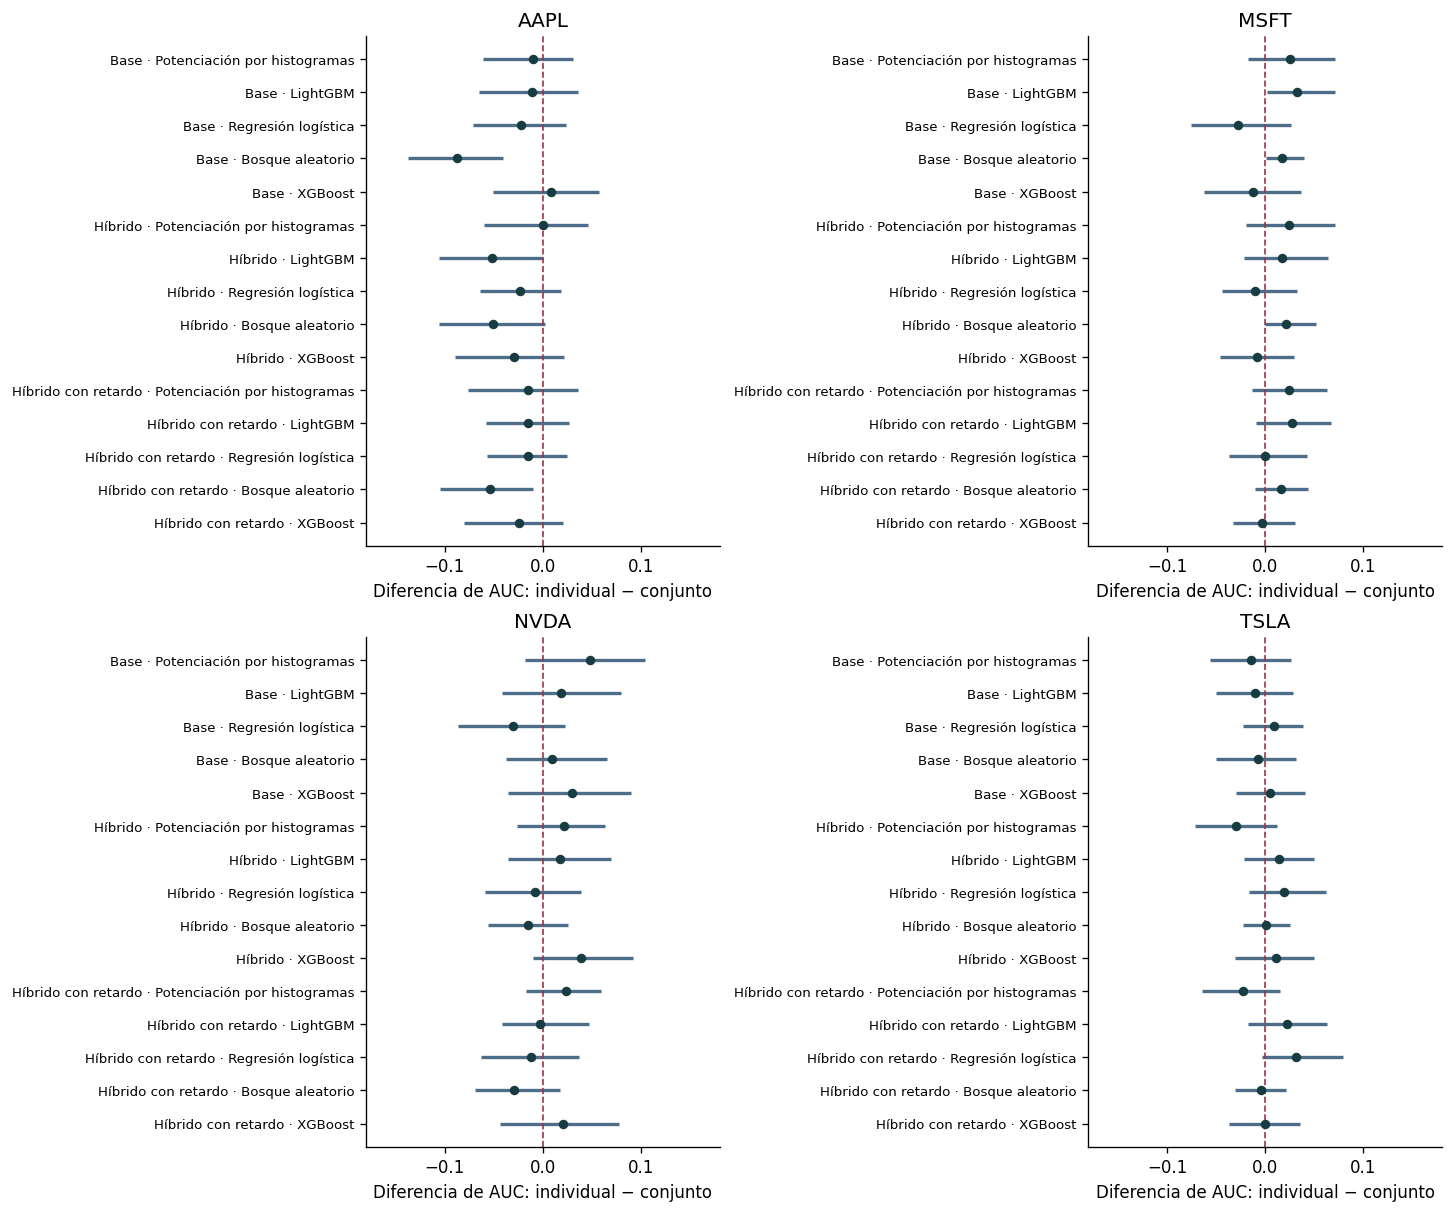

,mejora_clara,empeoramiento_claro
ticker,,
AAPL,0,3
MSFT,3,0
NVDA,0,0
TSLA,0,0


In [7]:
display(intervals[["ticker", "dataset_type", "model_name", "roc_auc", "auc_delta",
                   "delta_low", "delta_high"]].round(4))
fig, axes = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")
for ticker, ax in zip(COMPANIES, axes.flat):
    data = intervals[intervals.ticker == ticker].sort_values(["dataset_type", "model_name"]).reset_index(drop=True)
    y = np.arange(len(data))
    ax.hlines(y, data.delta_low, data.delta_high, color="#4d6d88", linewidth=2)
    ax.scatter(data.auc_delta, y, color="#173d43", s=22, zorder=3)
    ax.axvline(0, color="#9e3345", linestyle="--", linewidth=1)
    labels = [f"{LABELS[v]} · {MODEL_LABELS[m]}" for v, m in zip(data.dataset_type, data.model_name)]
    ax.set_yticks(y, labels, fontsize=8)
    ax.invert_yaxis()
    ax.set(title=ticker, xlabel="Diferencia de AUC: individual − conjunto", xlim=(-0.18, 0.18))
plt.show()
display(intervals.assign(mejora_clara=intervals.delta_low > 0,
                         empeoramiento_claro=intervals.delta_high < 0)
        .groupby("ticker")[["mejora_clara", "empeoramiento_claro"]].sum())

## 8. ¿Aportan noticias y retardo dentro de cada empresa?

Estas son comparaciones distintas a separar empresas. Aquí se mantiene fijo el entrenamiento individual: híbrido menos base y retardo menos híbrido, siempre con el mismo algoritmo. El AUC absoluto y el intervalo de su diferencia contestan preguntas diferentes. Se muestran únicamente los bloques de 20 sesiones para que todas las filas compartan el mismo procedimiento.

In [8]:
news_intervals = within[(within.block_sessions == 20) & within.dataset_type.isin(["hybrid", "lag_1"])]
display(news_intervals[["ticker", "dataset_type", "model_name", "reference_dataset",
                       "roc_auc", "auc_delta", "delta_low", "delta_high"]].round(4))
display(news_intervals.assign(mejora_clara=news_intervals.delta_low > 0,
                              empeoramiento_claro=news_intervals.delta_high < 0)
        .groupby(["ticker", "dataset_type"])[["mejora_clara", "empeoramiento_claro"]].sum())

,ticker,dataset_type,model_name,reference_dataset,roc_auc,auc_delta,delta_low,delta_high
5,AAPL,hybrid,hist_gradient_boosting,base,0.4709,0.0197,-0.0247,0.0717
6,AAPL,hybrid,lightgbm,base,0.4355,-0.0277,-0.0639,0.0084
7,AAPL,hybrid,logistic_regression,base,0.4458,0.0188,-0.0440,0.0656
8,AAPL,hybrid,random_forest,base,0.4414,0.0001,-0.0305,0.0356
9,AAPL,hybrid,xgboost,base,0.4507,-0.0156,-0.0542,0.0222
10,AAPL,lag_1,hist_gradient_boosting,hybrid,0.4702,-0.0007,-0.0471,0.0466
12,AAPL,lag_1,lightgbm,hybrid,0.4668,0.0312,-0.0016,0.0684
14,AAPL,lag_1,logistic_regression,hybrid,0.4536,0.0078,-0.0101,0.0262
15,AAPL,lag_1,random_forest,hybrid,0.4411,-0.0002,-0.0248,0.0236
16,AAPL,lag_1,xgboost,hybrid,0.4639,0.0131,-0.0153,0.0440


mejora_clara  empeoramiento_claro
ticker dataset_type                                   
AAPL   hybrid                   0                    0
       lag_1                    0                    0
MSFT   hybrid                   0                    0
       lag_1                    0                    0
NVDA   hybrid                   0                    0
       lag_1                    0                    0
TSLA   hybrid                   0                    0
       lag_1                    0                    1

## 9. Estabilidad temporal y otras métricas

El AUC de todas las sesiones no es igual al promedio de AUC de los bloques. Cambios de calibración entre bloques pueden alterar la ordenación de las probabilidades al agruparlas. La tabla completa evita ocultar esa diferencia. Las métricas basadas en clases usan siempre el umbral fijo de 0,5.

In [9]:
individual_metrics = learned[learned.approach == "individual"]
display(individual_metrics[["ticker", "dataset_type", "model_name", "roc_auc", "mean_outer_auc",
                            "std_outer_auc", "accuracy", "balanced_accuracy", "f1_macro", "mcc"]].round(4))
fold_table = blocks[(blocks.scope == "outer_fold") & (blocks.approach == "individual")
                    & (blocks.model_name != "dummy")].pivot(
    index=["ticker", "model_name", "dataset_type"], columns="group", values="roc_auc")
display(fold_table.rename_axis(columns="Bloque externo").round(4))

,ticker,dataset_type,model_name,roc_auc,mean_outer_auc,std_outer_auc,accuracy,balanced_accuracy,f1_macro,mcc
2,AAPL,base,hist_gradient_boosting,0.4512,0.4512,0.0235,0.4250,0.4301,0.4247,-0.1404
4,AAPL,base,lightgbm,0.4632,0.4587,0.0307,0.4647,0.4663,0.4644,-0.0672
6,AAPL,base,logistic_regression,0.4270,0.4241,0.0524,0.5208,0.4845,0.3977,-0.0532
8,AAPL,base,random_forest,0.4413,0.4360,0.0208,0.4575,0.4484,0.4462,-0.1049
10,AAPL,base,xgboost,0.4663,0.4626,0.0260,0.4846,0.4775,0.4767,-0.0454
12,AAPL,hybrid,hist_gradient_boosting,0.4709,0.4725,0.0334,0.4684,0.4648,0.4648,-0.0703
14,AAPL,hybrid,lightgbm,0.4355,0.4352,0.0082,0.4467,0.4500,0.4467,-0.0999
16,AAPL,hybrid,logistic_regression,0.4458,0.4408,0.0104,0.5045,0.4883,0.4778,-0.0250
18,AAPL,hybrid,random_forest,0.4414,0.4385,0.0240,0.4774,0.4663,0.4625,-0.0692
20,AAPL,hybrid,xgboost,0.4507,0.4526,0.0155,0.4485,0.4414,0.4405,-0.1182


Bloque externo                                 1.0     2.0     3.0
ticker model_name             dataset_type                        
AAPL   hist_gradient_boosting base          0.4615  0.4243  0.4679
                              hybrid        0.4377  0.4752  0.5045
                              lag_1         0.4549  0.4770  0.4672
       lightgbm               base          0.4792  0.4736  0.4234
                              hybrid        0.4331  0.4442  0.4282
                              lag_1         0.4732  0.4587  0.4652
       logistic_regression    base          0.3976  0.4844  0.3903
                              hybrid        0.4333  0.4364  0.4527
                              lag_1         0.4417  0.4506  0.4621
       random_forest          base          0.4150  0.4365  0.4565
                              hybrid        0.4190  0.4313  0.4652
                              lag_1         0.4197  0.4608  0.4535
       xgboost                base          0.4326  0.4789  0.4763
                              hybrid        0.4354  0.4655  0.4569
                              lag_1         0.4417  0.4665  0.4651
MSFT   hist_gradient_boosting base          0.5182  0.4991  0.6075
                              hybrid        0.4900  0.5069  0.5975
                              lag_1         0.4737  0.4907  0.5865
       lightgbm               base          0.4562  0.5169  0.6151
                              hybrid        0.4576  0.5242  0.6066
                              lag_1         0.4712  0.5254  0.6083
       logistic_regression    base          0.5289  0.5195  0.5044
                              hybrid        0.4726  0.5210  0.5536
                              lag_1         0.4800  0.5228  0.5488
       random_forest          base          0.5180  0.5085  0.5912
                              hybrid        0.4632  0.5486  0.6258
                              lag_1         0.4625  0.5462  0.6184
       xgboost                base          0.4594  0.4852  0.5912
                              hybrid        0.4694  0.5345  0.6002
                              lag_1         0.4792  0.5103  0.5865
NVDA   hist_gradient_boosting base          0.4873  0.6191  0.5499
                              hybrid        0.5049  0.5327  0.5190
                              lag_1         0.4912  0.5730  0.5245
       lightgbm               base          0.4902  0.5806  0.5514
                              hybrid        0.4987  0.5576  0.5591
                              lag_1         0.5093  0.5611  0.5657
       logistic_regression    base          0.5244  0.5534  0.5360
                              hybrid        0.5476  0.5260  0.5675
                              lag_1         0.5499  0.5229  0.5515
       random_forest          base          0.4822  0.5670  0.5345
                              hybrid        0.5226  0.5513  0.5622
                              lag_1         0.5083  0.5652  0.5478
       xgboost                base          0.4985  0.6039  0.5522
                              hybrid        0.5100  0.5772  0.5511
                              lag_1         0.5087  0.5870  0.5644
TSLA   hist_gradient_boosting base          0.4540  0.5211  0.5502
                              hybrid        0.5180  0.5388  0.5190
                              lag_1         0.4885  0.5315  0.4944
       lightgbm               base          0.4889  0.5325  0.5346
                              hybrid        0.5324  0.5498  0.5177
                              lag_1         0.5177  0.5727  0.5275
       logistic_regression    base          0.5269  0.5531  0.4986
                              hybrid        0.5285  0.5749  0.4892
                              lag_1         0.5220  0.5740  0.5045
       random_forest          base          0.5036  0.5411  0.5165
                              hybrid        0.5571  0.5637  0.5271
                              lag_1         0.5213  0.5784  0.5094
       xgboost                base          0.5

## 10. Resumen entre empresas sin mezclar escalas de probabilidades

El promedio macro da el mismo peso a las cuatro empresas y promedia sus AUC, en vez de mezclar probabilidades de cuatro estimadores con calibraciones diferentes. No es un modelo adicional ni una evaluación de cartera. Tampoco el promedio entre algoritmos debe interpretarse como una combinación de sus predicciones.

In [10]:
macro_table = macro[macro.model_name != "dummy"].pivot(
    index="model_name", columns=["approach", "dataset_type"], values="roc_auc")
macro_table = macro_table.reindex(columns=pd.MultiIndex.from_product([["joint", "individual"], VARIANTS]))
macro_table.index = macro_table.index.map(MODEL_LABELS)
macro_table.columns = [f"{'Conjunto' if a == 'joint' else 'Individual'}: {LABELS[v]}" for a, v in macro_table.columns]
display(macro_table.round(4))
descriptive = learned.groupby(["ticker", "approach", "dataset_type"]).roc_auc.mean().unstack(["approach", "dataset_type"])
display(Markdown("**Media descriptiva de los cinco algoritmos por empresa**, sin elegir ganadores:"))
display(descriptive.round(4))

,Conjunto: Base,Conjunto: Híbrido,Conjunto: Híbrido con retardo,Individual: Base,Individual: Híbrido,Individual: Híbrido con retardo
model_name,,,,,,
Potenciación por histogramas,0.4846,0.4961,0.4934,0.4965,0.5000,0.4960
LightGBM,0.4899,0.4938,0.4950,0.4972,0.4929,0.5028
Regresión logística,0.5015,0.4987,0.4961,0.4839,0.4934,0.4968
Bosque aleatorio,0.5057,0.5054,0.5091,0.4884,0.4944,0.4911
XGBoost,0.4918,0.4988,0.4996,0.4992,0.5016,0.4978


**Media descriptiva de los cinco algoritmos por empresa**, sin elegir ganadores:

approach     individual                   joint                
dataset_type       base  hybrid   lag_1    base  hybrid   lag_1
ticker                                                         
AAPL             0.4498  0.4489  0.4591  0.4747  0.4799  0.4840
MSFT             0.5033  0.5021  0.4997  0.4965  0.4934  0.4870
NVDA             0.5074  0.5120  0.5135  0.4923  0.5013  0.5136
TSLA             0.5117  0.5227  0.5153  0.5153  0.5197  0.5099

## 11. Lectura de los resultados

La siguiente síntesis se calcula a partir de las tablas: cuenta diferencias observadas y sus intervalos. No convierte el mejor resultado externo en una selección válida para producción.

Para interpretar una posible mejora deberían coincidir una diferencia favorable frente al mismo algoritmo conjunto, estabilidad en varios bloques y métricas equilibradas razonables. Conviene confirmar cualquier hipótesis en nuevas fechas no utilizadas para diseñar el experimento.

In [11]:
for ticker in COMPANIES:
    group = intervals[intervals.ticker == ticker]
    local = individual_metrics[individual_metrics.ticker == ticker]
    best = local.loc[local.roc_auc.idxmax()]
    display(Markdown(
        f"**{ticker}:** el entrenamiento individual aumenta el AUC observado en "
        f"{int((group.auc_delta > 0).sum())} de {len(group)} combinaciones. "
        f"{int((group.delta_low > 0).sum())} intervalos quedan por encima de cero y "
        f"{int((group.delta_high < 0).sum())} por debajo. "
        f"El máximo descriptivo es {MODEL_LABELS[best.model_name]}, {LABELS[best.dataset_type]}: "
        f"AUC **{best.roc_auc:.4f}**, exactitud **{best.accuracy:.2%}**, "
        f"exactitud equilibrada **{best.balanced_accuracy:.2%}**. "
        "**Este máximo se identifica después de ver la prueba y no es una validación independiente.**"))
display(Markdown(
    f"**Conjunto de comparaciones:** {(intervals.auc_delta > 0).sum()}/60 diferencias positivas; "
    f"{(intervals.delta_low > 0).sum()} intervalos positivos y {(intervals.delta_high < 0).sum()} negativos. "
    "La ausencia de una diferencia clara no demuestra equivalencia ni que ningún enfoque pueda funcionar."))

**AAPL:** el entrenamiento individual aumenta el AUC observado en 2 de 15 combinaciones. 0 intervalos quedan por encima de cero y 3 por debajo. El máximo descriptivo es Potenciación por histogramas, Híbrido: AUC **0.4709**, exactitud **46.84%**, exactitud equilibrada **46.48%**. **Este máximo se identifica después de ver la prueba y no es una validación independiente.**

**MSFT:** el entrenamiento individual aumenta el AUC observado en 9 de 15 combinaciones. 3 intervalos quedan por encima de cero y 0 por debajo. El máximo descriptivo es Potenciación por histogramas, Base: AUC **0.5141**, exactitud **47.74%**, exactitud equilibrada **49.63%**. **Este máximo se identifica después de ver la prueba y no es una validación independiente.**

**NVDA:** el entrenamiento individual aumenta el AUC observado en 9 de 15 combinaciones. 0 intervalos quedan por encima de cero y 0 por debajo. El máximo descriptivo es XGBoost, Híbrido: AUC **0.5304**, exactitud **50.99%**, exactitud equilibrada **52.45%**. **Este máximo se identifica después de ver la prueba y no es una validación independiente.**

**TSLA:** el entrenamiento individual aumenta el AUC observado en 8 de 15 combinaciones. 0 intervalos quedan por encima de cero y 0 por debajo. El máximo descriptivo es Regresión logística, Híbrido con retardo: AUC **0.5324**, exactitud **51.18%**, exactitud equilibrada **50.76%**. **Este máximo se identifica después de ver la prueba y no es una validación independiente.**

**Conjunto de comparaciones:** 28/60 diferencias positivas; 3 intervalos positivos y 3 negativos. La ausencia de una diferencia clara no demuestra equivalencia ni que ningún enfoque pueda funcionar.

## 12. Conclusión y reproducción

**No hay una mejora general por separar empresas.** AAPL empeora; MSFT presenta pequeñas mejoras relativas; NVDA y TSLA dependen de la variante y el algoritmo. De 60 diferencias, 28 son positivas; tres intervalos quedan por encima de cero en MSFT y tres por debajo en AAPL. Los otros 54 contienen cero. No se ha corregido por comparaciones múltiples.

Las tres mejoras relativas de MSFT no prueban una capacidad predictiva absoluta: sus intervalos de AUC siguen incluyendo 0,5. En las 40 comparaciones internas de noticias y retardo no hay ningún intervalo totalmente positivo. El mayor AUC descriptivo individual es 0,5324 en TSLA con regresión logística y retardo, pero se identifica retrospectivamente y su intervalo incluye 0,5.

Conservaría este experimento como contraste para la memoria, sin sustituir automáticamente el enfoque conjunto. La reducción de muestra, la cobertura desigual de noticias y la reutilización del histórico siguen siendo limitaciones. El [análisis completo](../reports/experiments/per-company-20260916/analysis.md) desarrolla las cifras y la interpretación.

Desde la raíz del repositorio, con las dependencias del proyecto instaladas:

```powershell
python -m src.experiments.run_per_company --run-dir reports/experiments/per-company-NUEVA-EJECUCION
```

El identificador debe ser nuevo: nunca se sobrescribe una ejecución anterior. El entrenamiento completo vuelve a ajustar los modelos conjuntos e individuales y genera sus métricas e intervalos. No consulta APIs de noticias.

- `src/experiments/run_per_company.py`: ejecutor del experimento.
- `reports/experiments/per-company-20260916/metrics/`: métricas e intervalos comparados.
- `reports/experiments/per-company-20260916/companies/<empresa>/`: predicciones, búsqueda interna y métricas por empresa.
- `reports/experiments/per-company-20260916/joint/`: referencia conjunta reentrenada.
- `models/experiments/per-company-20260916/<empresa>/`: modelos locales, excluidos de Git.
- `data/experiments/per-company-20260916/<empresa>/`: noticias y variables locales, excluidas de Git.
- `artifacts/snapshots/per-company-20260916/`: instantánea local del código.
- `manifest.json`: configuración, versiones, procedencia y huellas de los archivos.

### Limitaciones que permanecen

Menos observaciones por estimador, cobertura de noticias desigual y cambiante, publicación como aproximación a disponibilidad real, falta de una muestra futura intacta, múltiples comparaciones y ausencia de evaluación económica. Separar empresas no resuelve automáticamente estos problemas. SPY continúa excluido y no se modifican las conclusiones de la memoria ni los resultados finales sin una revisión posterior.